In [90]:
import pandas as pd
import numpy as np

# Data Preparation

In [91]:
datadir = '../Data/'
datafile = datadir + "25-26-Womens-Basketball.csv"

In [92]:
data = pd.read_csv(datafile)
data.head()

,Team,Date,wins_before_date,losses_before_date,opponent_wins_before_date,opponent_losses_before_date,Opponent,Team_FG_pct,Team_2_pct,Team_3_pct,Team_FT_pct,Team_Points,Opp_FG_pct,Opp_2_pct,Opp_3_pct,Opp_FT_pct,Opp_Points
0,Dean,2025-11-04,0,0,0,0,Vermont,0.234,0.233,0.235,0.500,31,0.683,0.754,0.520,0.750,137
1,Coastal Georgia,2025-12-12,0,0,6,3,Ga. Southern,0.338,0.382,0.302,0.600,74,0.685,0.778,0.536,0.724,136
2,Charleston,2025-11-03,0,0,0,0,Covenant,0.548,0.641,0.345,0.852,135,0.239,0.400,0.115,0.800,41
3,MVSU,2025-12-06,1,6,9,1,Oklahoma St.,0.293,0.298,0.273,0.750,46,0.672,0.833,0.484,0.875,133
4,Saint Louis,2025-12-28,6,7,0,0,Stl Pharmacy,0.576,0.681,0.447,0.773,132,0.268,0.306,0.182,0.846,53


In [93]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

In [94]:
data['games_played_before_date'] = data['wins_before_date'] + data['losses_before_date']
data['opponent_games_played_before_date'] = data['opponent_wins_before_date'] + data['opponent_losses_before_date']
data['win_pct_before_date'] = np.where(
    data['games_played_before_date'] > 0,
    data['wins_before_date'] / data['games_played_before_date'],
    0
)
data['opponent_win_pct_before_date'] = np.where(
    data['opponent_games_played_before_date'] > 0,
    data['opponent_wins_before_date'] / data['opponent_games_played_before_date'],
    0
)
data['Win-Loss'] = np.where((data['Team_Points'] > data['Opp_Points']) , 'Win', 'Loss')
data.head()

,Team,Date,wins_before_date,losses_before_date,opponent_wins_before_date,opponent_losses_before_date,Opponent,Team_FG_pct,Team_2_pct,Team_3_pct,...,Opp_FG_pct,Opp_2_pct,Opp_3_pct,Opp_FT_pct,Opp_Points,games_played_before_date,opponent_games_played_before_date,win_pct_before_date,opponent_win_pct_before_date,Win-Loss
0,Dean,2025-11-04,0,0,0,0,Vermont,0.234,0.233,0.235,...,0.683,0.754,0.520,0.750,137,0,0,0.000000,0.000000,Loss
1,Coastal Georgia,2025-12-12,0,0,6,3,Ga. Southern,0.338,0.382,0.302,...,0.685,0.778,0.536,0.724,136,0,9,0.000000,0.666667,Loss
2,Charleston,2025-11-03,0,0,0,0,Covenant,0.548,0.641,0.345,...,0.239,0.400,0.115,0.800,41,0,0,0.000000,0.000000,Win
3,MVSU,2025-12-06,1,6,9,1,Oklahoma St.,0.293,0.298,0.273,...,0.672,0.833,0.484,0.875,133,7,10,0.142857,0.900000,Loss
4,Saint Louis,2025-12-28,6,7,0,0,Stl Pharmacy,0.576,0.681,0.447,...,0.268,0.306,0.182,0.846,53,13,0,0.461538,0.000000,Win


In [95]:
features = ['Team', 'Opponent', 'games_played_before_date', 'opponent_games_played_before_date', 'win_pct_before_date', 'opponent_win_pct_before_date']
x = data [features]
y = data ['Win-Loss']
x = pd.get_dummies(x, columns=['Team', 'Opponent'], drop_first=True)

In [96]:
data['Win-Loss'].value_counts()

Win-Loss
Win     3012
Loss    3011
Name: count, dtype: int64

In [97]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [98]:
print (x_train.size, x_test.size, y_train.size, y_test.size)

4957722 1239945 4818 1205


# Logistic Regression

In [99]:
logreg = LogisticRegression(C=1e3, max_iter=5000)
lr_model = logreg.fit(x_train, y_train)

In [100]:
print (' Model details:')
print (' -  intercept : ', lr_model.intercept_)
print (' -  coeff : ', lr_model.coef_)

 Model details:
 -  intercept :  [0.61735624]
 -  coeff :  [[ 0.13996331 -0.13352851 -2.24070401 ...  0.78146789  3.3032505
  -2.29435347]]


In [101]:
lr_y_pred_train = lr_model.predict(x_train)
lr_y_pred_test = lr_model.predict(x_test)

In [102]:
from sklearn.metrics import confusion_matrix

In [103]:
CM = confusion_matrix(y_test, lr_y_pred_test)
print (CM)

[[456 147]
 [162 440]]


In [104]:
print(metrics.accuracy_score(y_test, lr_y_pred_test))

0.7435684647302905


In [105]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_test_num = (y_test == 'Win').astype(int)

lr_probs = lr_model.predict_proba(x_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test_num, lr_probs)
lr_auc = roc_auc_score(y_test_num, lr_probs)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.8189175936485897


# Random Forest

In [106]:

from sklearn.ensemble import RandomForestClassifier

In [107]:
rf_model = RandomForestClassifier(max_depth=2, random_state=0)

In [108]:
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [109]:
rf_y_pred_train = rf_model.predict(x_train)
rf_y_pred_test = rf_model.predict(x_test)

In [110]:
CM = confusion_matrix(y_test, rf_y_pred_test)
print (CM)

[[495 108]
 [269 333]]


In [111]:
print(metrics.accuracy_score(y_test, rf_y_pred_test))

0.6871369294605809


In [112]:
rf_probs = rf_model.predict_proba(x_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test_num, rf_probs)
rf_auc = roc_auc_score(y_test_num, rf_probs)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.7782653730241372


# Explainer Methods for Logistic Regression

In [113]:
import lime
import lime.lime_tabular
import shap
shap.initjs()

In [114]:
lr_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train.values,
    feature_names=x_train.columns.tolist(),
    class_names=lr_model.classes_.tolist(),
    discretize_continuous=True
)
lr_predict_fn = lambda arr: lr_model.predict_proba(pd.DataFrame(arr, columns=x_train.columns))

In [115]:
i = np.random.randint(0, x_test.shape[0])
print (i)

lr_lime_exp = lr_lime_explainer.explain_instance(x_test.iloc[i].values, lr_predict_fn, num_features=10)

286


In [116]:
print(lr_model.predict_proba(x_test.iloc[[i]]))
lr_lime_exp.as_list()

[[0.98156229 0.01843771]]


[('Opponent_Baylor <= 0.00', 0.41787383834425745),
 ('Team_Johnson <= 0.00', 0.34913796333791947),
 ('Team_Huston-Tilotson <= 0.00', 0.3400210591388984),
 ('Opponent_Trinity Baptist <= 0.00', -0.3154801624121688),
 ('Team_Erskine <= 0.00', 0.2823993309913518),
 ('Team_Mercy <= 0.00', 0.2489254621531065),
 ('Opponent_Arizona St. <= 0.00', 0.2455503705261047),
 ('Opponent_Warren Wilson <= 0.00', -0.2432263508878668),
 ('Opponent_Ithaca <= 0.00', -0.2424781104330893),
 ('Team_New England Col. <= 0.00', 0.1810995725515378)]

In [117]:
lr_shap_explainer = shap.LinearExplainer(lr_model, x_train)
lr_shap_values = lr_shap_explainer.shap_values(x_test)
lr_shap_exp = lr_shap_explainer(x_test)

Team                                     Arkansas
Date                                   2025-12-28
wins_before_date                               11
losses_before_date                              3
opponent_wins_before_date                      10
opponent_losses_before_date                     3
Opponent                             Arkansas St.
Team_FG_pct                                  0.39
Team_2_pct                                  0.395
Team_3_pct                                  0.381
Team_FT_pct                                 0.818
Team_Points                                    72
Opp_FG_pct                                  0.386
Opp_2_pct                                   0.568
Opp_3_pct                                   0.239
Opp_FT_pct                                   0.75
Opp_Points                                     81
games_played_before_date                       14
opponent_games_played_before_date              13
win_pct_before_date                      0.785714


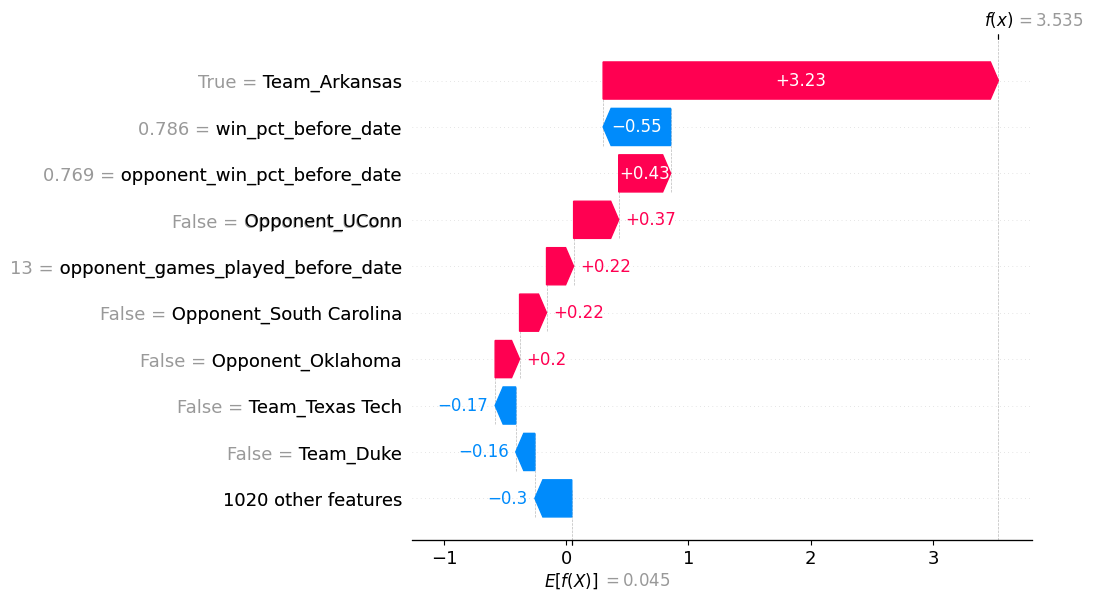

In [118]:
i = np.random.randint(0, x_test.shape[0])
print(data.loc[x_test.index[i]])
shap.plots.waterfall(lr_shap_exp[i])

# Explainer Methods for Random Forest

In [119]:
rf_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train.values,
    feature_names=x_train.columns.tolist(),
    class_names=rf_model.classes_.tolist(),
    discretize_continuous=True
)
rf_predict_fn = lambda arr: rf_model.predict_proba(pd.DataFrame(arr, columns=x_train.columns))

In [120]:
i = np.random.randint(0, x_test.shape[0])
print (i)

rf_lime_exp = rf_lime_explainer.explain_instance(x_test.iloc[i].values, rf_predict_fn, num_features=10)

62


In [121]:
print(rf_model.predict_proba(x_test.iloc[[i]]))
rf_lime_exp.as_list()

[[0.52026215 0.47973785]]


[('Team_Bellarmine <= 0.00', 0.03236967023164574),
 ('Team_FDU <= 0.00', -0.03157733555455634),
 ('Opponent_Valparaiso <= 0.00', -0.025180033148709875),
 ('Opponent_Western Caro. <= 0.00', -0.024003365373996374),
 ('Team_Cal St. L.A. <= 0.00', 0.013841594540238911),
 ('Opponent_Randolph <= 0.00', 0.01340878583828999),
 ('Opponent_Point <= 0.00', 0.010097322481099121),
 ('Opponent_Transylvania <= 0.00', 0.0100973224810991),
 ('Opponent_Walla Walla <= 0.00', 0.010092948077861255),
 ('Team_West Ga. <= 0.00', 0.010088573687680331)]

In [122]:
rf_shap_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_shap_explainer.shap_values(x_test)
rf_shap_exp = rf_shap_explainer(x_test)

Team                                 Chattanooga
Date                                  2025-11-06
wins_before_date                               1
losses_before_date                             0
opponent_wins_before_date                      1
opponent_losses_before_date                    0
Opponent                                 Florida
Team_FG_pct                                0.333
Team_2_pct                                  0.32
Team_3_pct                                 0.353
Team_FT_pct                                0.621
Team_Points                                   52
Opp_FG_pct                                 0.522
Opp_2_pct                                  0.591
Opp_3_pct                                  0.391
Opp_FT_pct                                 0.577
Opp_Points                                    94
games_played_before_date                       1
opponent_games_played_before_date              1
win_pct_before_date                          1.0
opponent_win_pct_bef

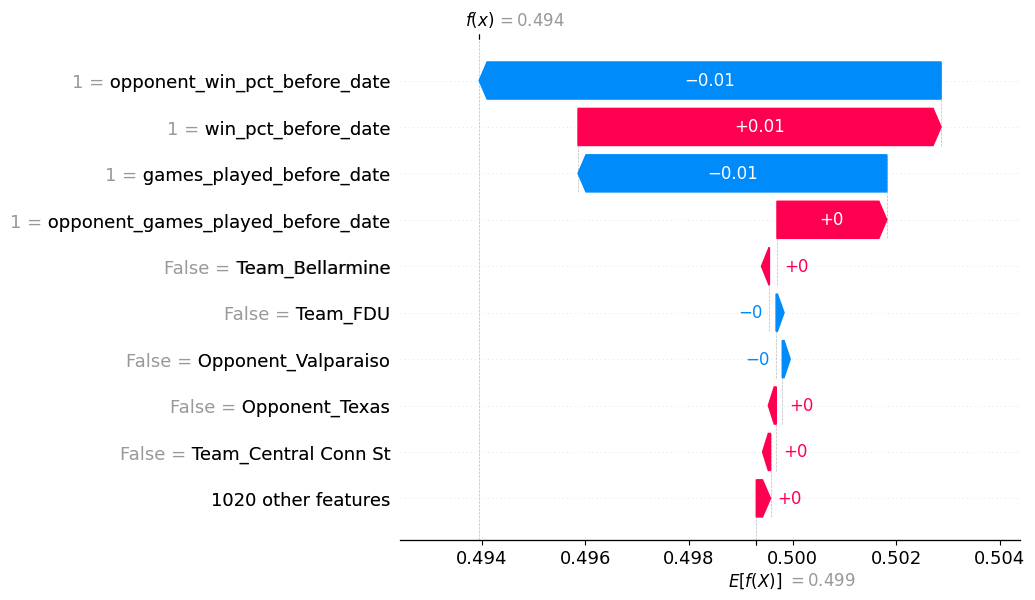

In [123]:
i = np.random.randint(0, x_test.shape[0])
print(data.loc[x_test.index[i]])
shap.plots.waterfall(rf_shap_exp[i, :, 1])

# South Carolina vs UCONN Custom Game Explanations

In [124]:
new_game = pd.DataFrame([
    {
        'Team': 'UConn',
        'Opponent': 'South Carolina',
        'games_played_before_date': 39,
        'opponent_games_played_before_date': 39,
        'win_pct_before_date': 0.97435,
        'opponent_win_pct_before_date': 0.92307,
    }
])

new_game_encoded = pd.get_dummies(new_game, columns=['Team', 'Opponent'], drop_first=True)
new_game_encoded = new_game_encoded.reindex(columns=x_train.columns, fill_value=0)

print(new_game)
print('Logistic regression class:', lr_model.predict(new_game_encoded)[0])
print('Logistic regression probs:', lr_model.predict_proba(new_game_encoded)[0])
print('Random forest class:', rf_model.predict(new_game_encoded)[0])
print('Random forest probs:', rf_model.predict_proba(new_game_encoded)[0])

    Team        Opponent  games_played_before_date  \
0  UConn  South Carolina                        39   

   opponent_games_played_before_date  win_pct_before_date  \
0                                 39              0.97435   

   opponent_win_pct_before_date  
0                       0.92307  
Logistic regression class: Win
Logistic regression probs: [0.47221184 0.52778816]
Random forest class: Loss
Random forest probs: [0.50145931 0.49854069]


# Custom Game Explanations

Logistic regression probabilities: [0.47221184 0.52778816]


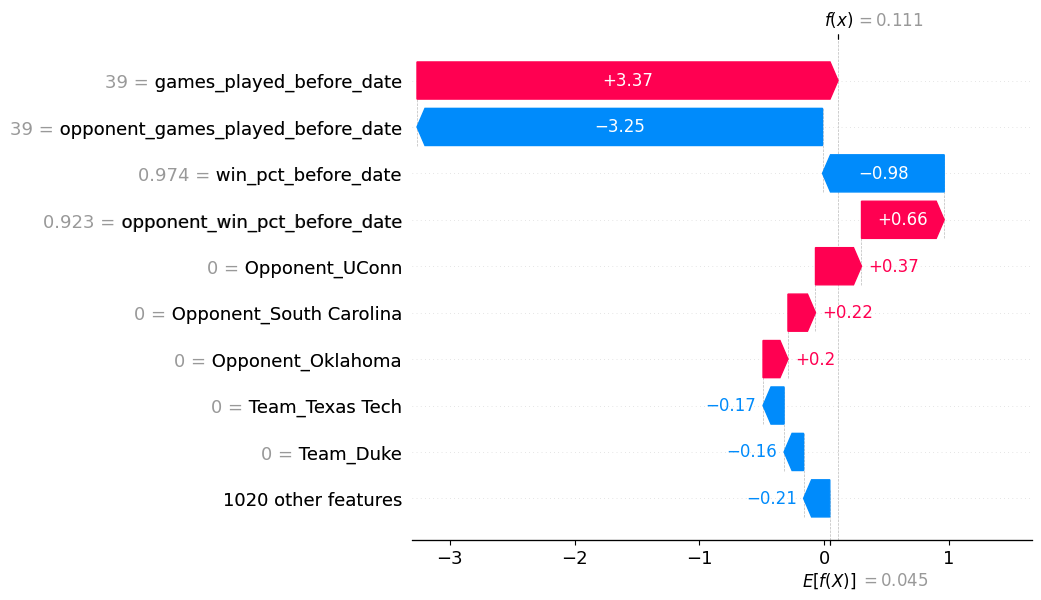

In [125]:
lr_shap_explainer = shap.LinearExplainer(lr_model, x_train)
lr_custom_exp = lr_shap_explainer(new_game_encoded)
print('Logistic regression probabilities:', lr_model.predict_proba(new_game_encoded)[0])
shap.plots.waterfall(lr_custom_exp[0])


Random forest probabilities: [0.50145931 0.49854069]


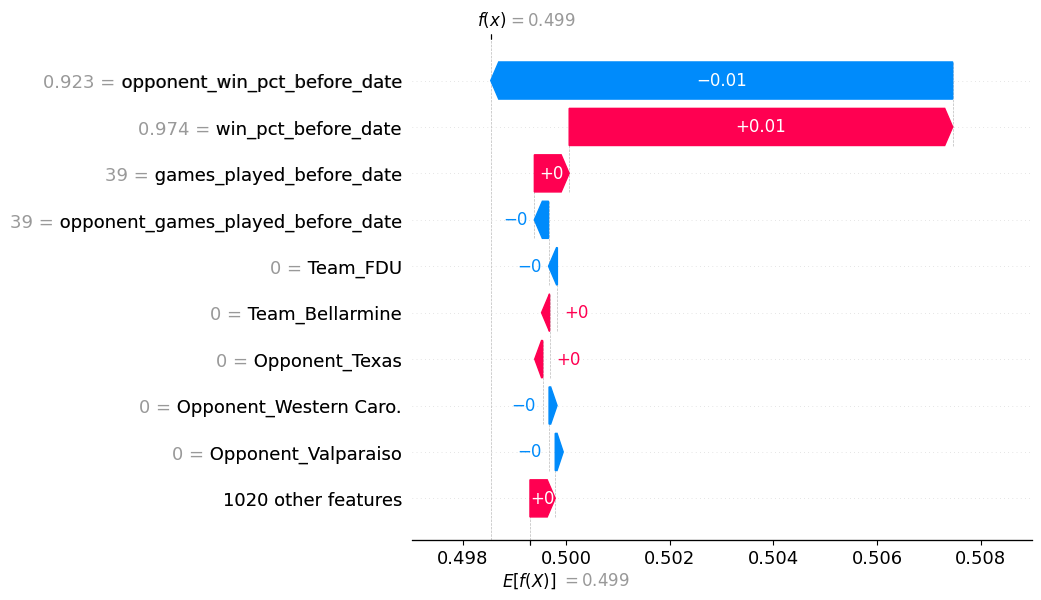

In [126]:
rf_shap_explainer = shap.TreeExplainer(rf_model)
rf_custom_exp = rf_shap_explainer(new_game_encoded)
win_idx = list(rf_model.classes_).index('Win')
print('Random forest probabilities:', rf_model.predict_proba(new_game_encoded)[0])
shap.plots.waterfall(rf_custom_exp[0, :, win_idx])


In [127]:
lr_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train.values,
    feature_names=x.columns.tolist(),
    class_names=lr_model.classes_.tolist(),
    discretize_continuous=True
)
lr_predict_fn = lambda arr: lr_model.predict_proba(pd.DataFrame(arr, columns=x_train.columns))
lr_lime_exp = lr_lime_explainer.explain_instance(
    new_game_encoded.values[0],
    lr_predict_fn,
    num_features=10
)
print('Logistic regression probabilities:', lr_model.predict_proba(new_game_encoded)[0])
lr_lime_exp.as_list()


Logistic regression probabilities: [0.47221184 0.52778816]


[('Team_Princeton <= 0.00', -0.4296584296672378),
 ('Team_Bloomfield <= 0.00', 0.42899715834058605),
 ('Team_Texas <= 0.00', -0.39493756585746165),
 ('Team_Southern Ill. <= 0.00', 0.37511268365981915),
 ('Opponent_Saint Mary (NE) <= 0.00', -0.33103056987402607),
 ('Team_Embry–Riddle (AZ) <= 0.00', 0.3235576964797146),
 ('Team_Albany St. (GA) <= 0.00', 0.2497780197290148),
 ('Opponent_Delaware <= 0.00', 0.2466768186685729),
 ('Team_Colby-Sawyer <= 0.00', 0.24014413346995883),
 ('Team_Molloy <= 0.00', 0.23541588192929006)]

In [128]:
rf_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train.values,
    feature_names=x.columns.tolist(),
    class_names=rf_model.classes_.tolist(),
    discretize_continuous=True
)
rf_predict_fn = lambda arr: rf_model.predict_proba(pd.DataFrame(arr, columns=x_train.columns))
rf_lime_exp = rf_lime_explainer.explain_instance(
    new_game_encoded.values[0],
    rf_predict_fn,
    num_features=10
)
print('Random forest probabilities:', rf_model.predict_proba(new_game_encoded)[0])
rf_lime_exp.as_list()


Random forest probabilities: [0.50145931 0.49854069]


[('Team_Bellarmine <= 0.00', 0.031795241887171026),
 ('Team_FDU <= 0.00', -0.028720021581707486),
 ('Opponent_Western Caro. <= 0.00', -0.028192688325125247),
 ('Opponent_UCLA <= 0.00', 0.023655165679310523),
 ('Opponent_Valparaiso <= 0.00', -0.02273853359040416),
 ('Opponent_Texas <= 0.00', 0.01939247268412258),
 ('Opponent_Cal Poly <= 0.00', 0.010294611874859944),
 ('Team_Molloy <= 0.00', 0.0102857036535904),
 ('Opponent_Talladega <= 0.00', -0.00828270221895437),
 ('Opponent_Ithaca <= 0.00', -0.008282702218954368)]

# Feature Importance Plots

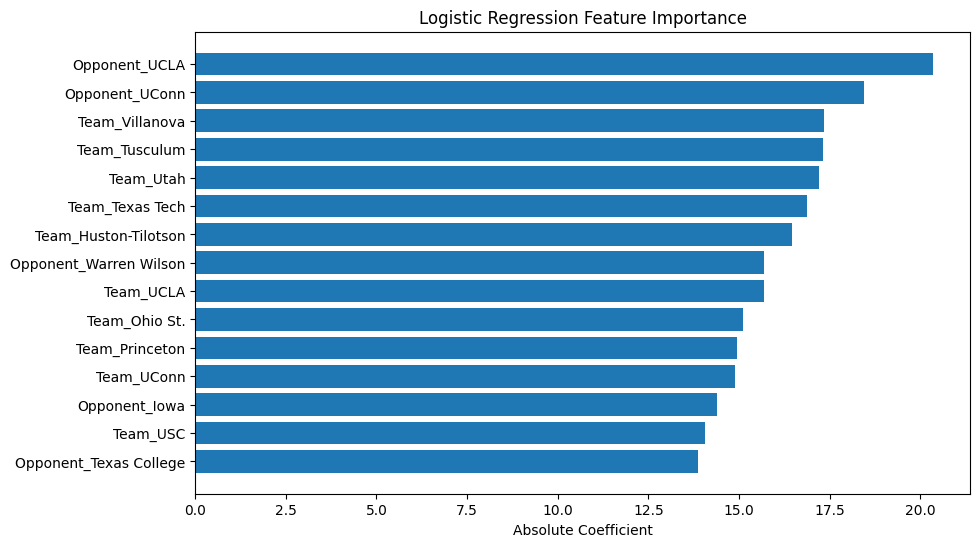

In [129]:
import matplotlib.pyplot as plt

lr_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': abs(lr_model.coef_[0])
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(lr_importance['feature'], lr_importance['importance'])
plt.gca().invert_yaxis()
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Absolute Coefficient')
plt.show()

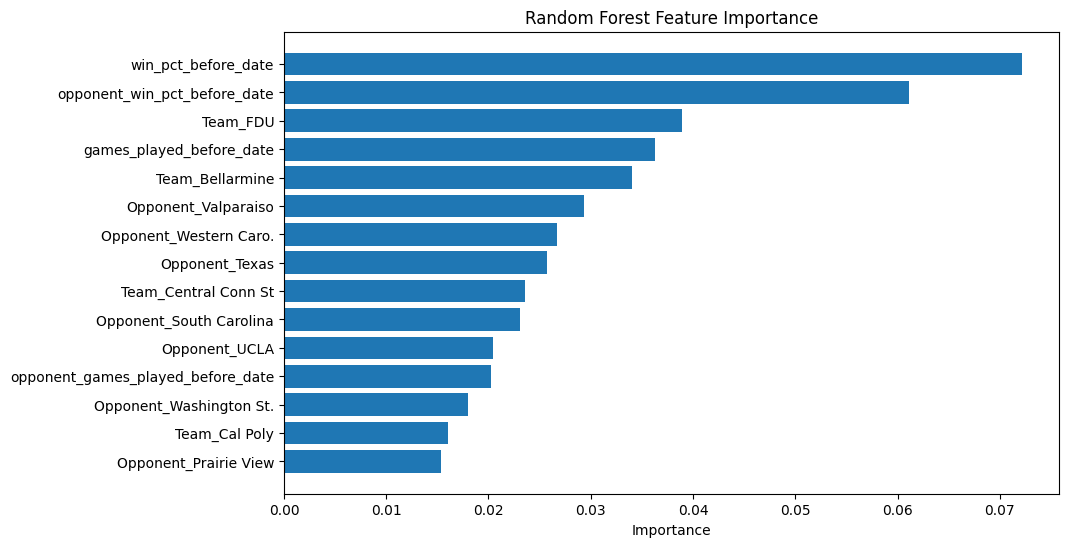

In [130]:
rf_importance = pd.DataFrame({
    'feature': x_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(rf_importance['feature'], rf_importance['importance'])
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()